In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('simulated_time_series.csv')

In [3]:
df.head()

,Time,Value
0,2018-02-01 00:00:00,8.793857
1,2018-02-01 01:00:00,12.401763
2,2018-02-01 02:00:00,10.743399
3,2018-02-01 03:00:00,11.203685
4,2018-02-01 04:00:00,11.600791


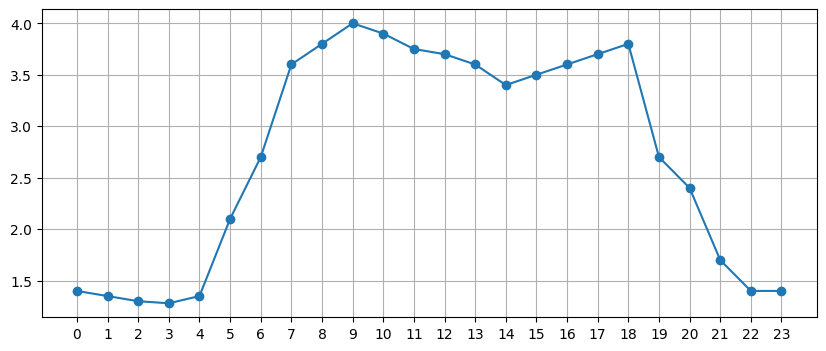

In [34]:

values = [1.4, 1.35, 1.3, 1.28 , 1.35, 2.1, 2.7, 3.6, 3.8 , 4.0 , 3.9 , 3.75, 3.7, 3.6 , 3.4, 3.5, 3.6, 3.7, 3.8, 2.7, 2.4, 1.7, 1.4 , 1.4]

plt.figure(figsize=(10, 4))  # Adjust width to stretch x-axis
plt.plot(values, marker='o')  # Add markers for better visibility
plt.xticks(range(len(values)))  # Ensure all x-ticks are shown
plt.grid(True)  # Optional: add grid for better readability
plt.show()

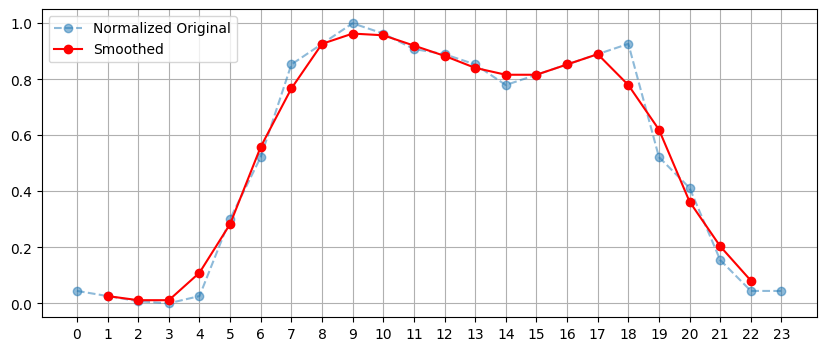

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

values = [1.4, 1.35, 1.3, 1.28 , 1.35, 2.1, 2.7, 3.6, 3.8 , 4.0 , 3.9 , 3.75, 
          3.7, 3.6 , 3.4, 3.5, 3.6, 3.7, 3.8, 2.7, 2.4, 1.7, 1.4 , 1.4]

def normalize(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

normalized_values = normalize(np.array(values))

def moving_average(data, window_size=3):
    return np.convolve(data, np.ones(window_size) / window_size, mode='valid')

smoothed_values = moving_average(normalized_values, window_size=3)

plt.figure(figsize=(10, 4))  
plt.plot(normalized_values, marker='o', linestyle='--', alpha=0.5, label="Normalized Original")  
plt.plot(range(1, len(smoothed_values) + 1), smoothed_values, marker='o', color='r', label="Smoothed")  
plt.xticks(range(len(values)))  
plt.grid(True)  
plt.legend()
plt.show()


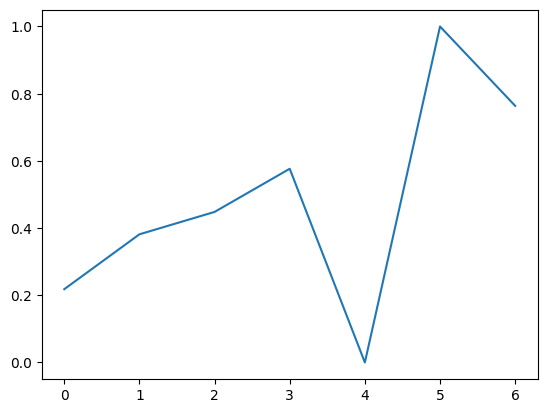

In [41]:
weekday_household = [66.93, 74.43, 77.49, 83.39,56.91,102.84,91.99]
normalized_weekday_household = normalize(np.array(weekday_household))
plt.plot(normalized_weekday_household)

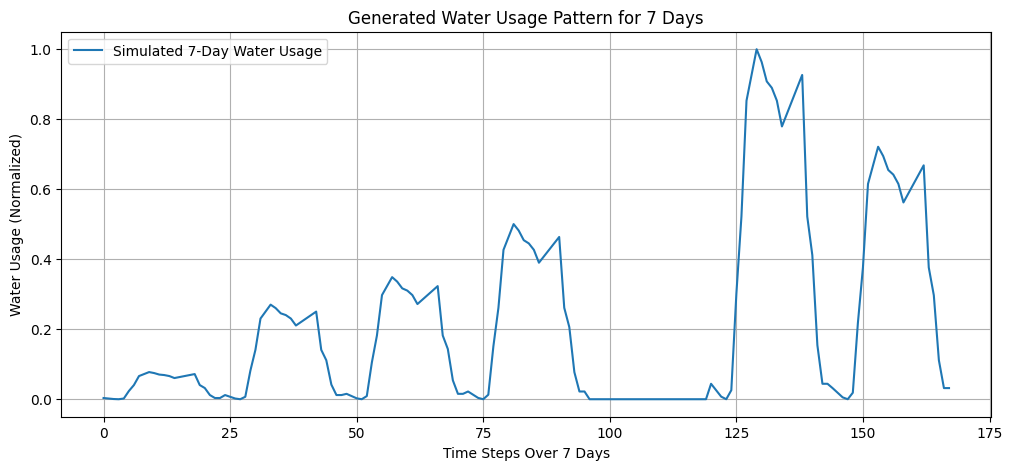

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Original daily usage pattern (this is the smoothed curve from before)
smoothed_values = np.array([1.4, 1.35, 1.3, 1.28, 1.35, 2.1, 2.7, 3.6, 
                            3.8, 4.0, 3.9, 3.75, 3.7, 3.6, 3.4, 3.5, 
                            3.6, 3.7, 3.8, 2.7, 2.4, 1.7, 1.4, 1.4])

# 7-day average water usage
weekday_household = np.array([66.93, 74.43, 77.49, 83.39, 63.91, 102.84, 91.99])

# Normalize function
def normalize(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

# Normalize the 7-day averages
normalized_weekday_household = normalize(weekday_household)

normalized_smoothed_values = normalize(smoothed_values)

# Generate 7 days of data based on smoothed_values scaled by daily averages
num_days = 7
time_steps = len(smoothed_values)

#np.random.seed(32)  # For reproducibility
all_days_data = []

for day in range(num_days):
    daily_variation = np.random.uniform(0.9, 1.1, time_steps)  # Small ±10% variation
    daily_curve = normalized_smoothed_values  *normalized_weekday_household[day] #* daily_variation  # Scale & vary
    all_days_data.append(daily_curve)

# Flatten the data for plotting
flattened_data = np.concatenate(all_days_data)

# Generate corresponding time axis (assuming hourly readings over 7 days)
time_axis = np.arange(len(flattened_data))

# Plot the 7-day simulated water usage pattern
plt.figure(figsize=(12, 5))
plt.plot(time_axis, flattened_data, linestyle='-', label="Simulated 7-Day Water Usage")
plt.xlabel("Time Steps Over 7 Days")
plt.ylabel("Water Usage (Normalized)")
plt.title("Generated Water Usage Pattern for 7 Days")
plt.grid(True)
plt.legend()
plt.show()


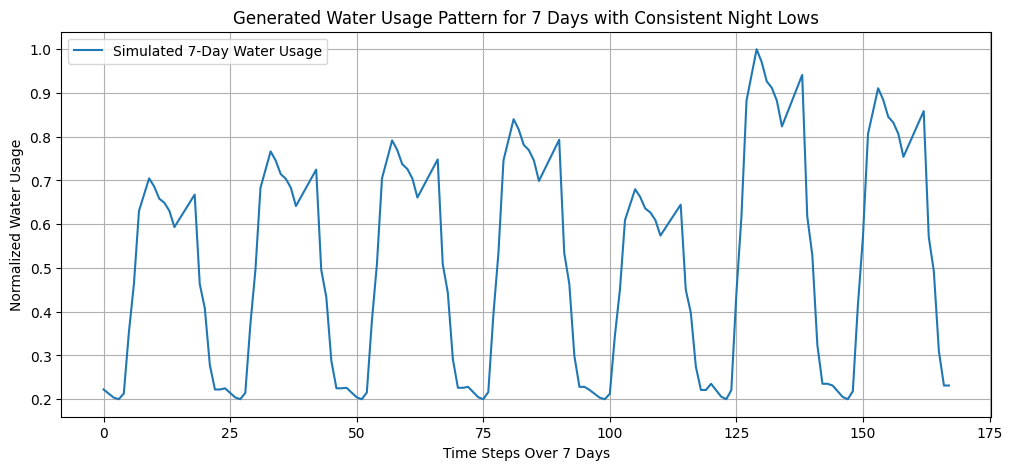

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

smoothed_values = np.array([1.4, 1.35, 1.3, 1.28, 1.35, 2.1, 2.7, 3.6, 
                            3.8, 4.0, 3.9, 3.75, 3.7, 3.6, 3.4, 3.5, 
                            3.6, 3.7, 3.8, 2.7, 2.4, 1.7, 1.4, 1.4])

weekday_household = np.array([66.93, 74.43, 77.49, 83.39, 63.91, 102.84, 91.99])

def normalize(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

normalized_smoothed = normalize(smoothed_values)
normalized_weekday = normalize(weekday_household)

scaling_offset = 0.2  # Baseline for low values
normalized_smoothed = normalized_smoothed * (1 - scaling_offset) + scaling_offset

num_days = 7
all_days_data = []

np.random.seed(42)  

for day in range(num_days):
    # Scale amplitude while keeping baseline fixed at 0.2
    amplitude_scaling = 0.6 + 0.4 * normalized_weekday[day]
    daily_curve = scaling_offset + (normalized_smoothed - scaling_offset) * amplitude_scaling
    all_days_data.append(daily_curve)

# Flatten the data for plotting
flattened_data = np.concatenate(all_days_data)

# def moving_average(data, window_size=3):
#     return np.convolve(data, np.ones(window_size) / window_size)

# smooth_flattened_data = moving_average(flattened_data, window_size=3)

# Generate corresponding time axis
time_axis = np.arange(len(flattened_data))

# Plot the generated water usage pattern
plt.figure(figsize=(12, 5))
plt.plot(time_axis, flattened_data, linestyle='-', label="Simulated 7-Day Water Usage")
plt.xlabel("Time Steps Over 7 Days")
plt.ylabel("Normalized Water Usage")
plt.title("Generated Water Usage Pattern for 7 Days with Consistent Night Lows")
plt.grid(True)
plt.legend()
plt.show()